# Phase 5 — Integrated Business Planning (IBP) Scenario Simulation

**Project:** End-to-End Aerospace Supply Chain Planning

## Business Problem

Phases 1-4 established a baseline: high service levels sustained by significant excess inventory, weak forecast/adjustment value-add, and supplier risk concentrated in a handful of underperforming suppliers. Before acting on the Phase 3 recommendation to reduce inventory, leadership needs to know how resilient that baseline position actually is under plausible disruption — a demand spike, a lead-time blowout, or a quality failure at the highest-risk supplier identified in Phase 4.

This phase answers:
- How much shortage risk emerges if Class A demand rises 20%?
- How much shortage risk emerges if lead times lengthen by 30% network-wide?
- What is the impact if the highest-risk supplier (SUP033, from Phase 4) has a quality event that blocks half its stock?
- What happens under a combined demand + lead-time shock?

## Objective

Run four IBP-style scenarios against the Phase 3 baseline inventory position and quantify shortage risk and inventory value at risk under each, to test whether the excess-inventory buffer identified in Phase 3 is doing useful work.


## Dataset

This phase consumes outputs from Phases 1, 3, and 4:

| File | Source | Contents |
|---|---|---|
| `master.parquet` | Phase 1 | Part master, used to identify parts dependent on SUP033 |
| `history_enriched.parquet` | Phase 1 | Loaded for consistency with earlier phases (not directly re-aggregated here) |
| `inventory_latest.parquet` | Phase 3 | Latest-week inventory position (days of coverage, inventory value, turns) used as the simulation baseline |
| `supplier_risk.parquet` | Phase 4 | Supplier risk ranking, used to confirm SUP033 as the highest-risk supplier for Scenario 3 |


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style('whitegrid')

PROJECT_ROOT = Path.cwd().parent
DATA_PHASE1 = PROJECT_ROOT / "data" / "processed" / "phase1"
DATA_PHASE3 = PROJECT_ROOT / "data" / "processed" / "phase3"
DATA_PHASE4 = PROJECT_ROOT / "data" / "processed" / "phase4"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed" / "phase5"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
IMAGES_DIR = PROJECT_ROOT / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)


## 1. Load Prior Phase Outputs

In [2]:
history_enriched = pd.read_parquet(DATA_PHASE1 / "history_enriched.parquet")
master = pd.read_parquet(DATA_PHASE1 / "master.parquet")
supplier_risk = pd.read_parquet(DATA_PHASE4 / "supplier_risk.parquet")
inventory_latest = pd.read_parquet(DATA_PHASE3 / "inventory_latest.parquet")

print("Loaded successfully")
print("history:", history_enriched.shape)
print("master:", master.shape)
print("supplier_risk:", supplier_risk.shape)
print("inventory_latest:", inventory_latest.shape)


Loaded successfully
history: (280800, 19)
master: (300, 18)
supplier_risk: (40, 20)
inventory_latest: (300, 14)


## 2. Baseline Position

In [3]:
baseline = inventory_latest.copy()

baseline_summary = baseline.groupby('criticality_class', observed=True).agg(
    inventory_value=('inventory_value', 'sum'),
    avg_days_cover=('days_of_coverage', 'mean'),
    avg_turns=('inventory_turns', 'mean'),
    num_parts=('part_id', 'count')
).round(1)

print("=== Baseline Position ===")
print(baseline_summary)
print(f"\nTotal Inventory Value: ${baseline['inventory_value'].sum():,.0f}")


=== Baseline Position ===
                   inventory_value  avg_days_cover  avg_turns  num_parts
criticality_class                                                       
A                      26757445.60          111.10       3.90         48
B                      37197331.20           86.60       5.10         95
C                      21122249.40           78.50       6.00        157

Total Inventory Value: $85,077,026


## 3. Scenario 1 — Class A Demand +20%

In [4]:
sc1 = baseline.copy()

# Assume demand +20% -> days of coverage falls ~20% and turns rise proportionally
mask_a = sc1['criticality_class'] == 'A'
sc1.loc[mask_a, 'days_of_coverage'] = sc1.loc[mask_a, 'days_of_coverage'] / 1.20
sc1.loc[mask_a, 'inventory_turns'] = sc1.loc[mask_a, 'inventory_turns'] * 1.20

# Shortage risk: Days of Coverage < Lead Time
sc1['shortage_risk'] = sc1['days_of_coverage'] < sc1['lead_time_days']

print("=== Scenario 1: Class A Demand +20% ===")
print("New Class A avg Days of Coverage:", round(sc1.loc[mask_a, 'days_of_coverage'].mean(), 1))
print("Class A parts at shortage risk:", sc1.loc[mask_a, 'shortage_risk'].sum())
print("Share of Class A at risk:", f"{sc1.loc[mask_a, 'shortage_risk'].mean():.1%}")


=== Scenario 1: Class A Demand +20% ===
New Class A avg Days of Coverage: 92.6
Class A parts at shortage risk: 0
Share of Class A at risk: 0.0%


## 4. Scenario 2 — Lead Time +30% (Network-Wide)

In [5]:
sc2 = baseline.copy()
sc2['lead_time_days_new'] = sc2['lead_time_days'] * 1.30

# Shortage risk against the new, longer lead time
sc2['shortage_risk'] = sc2['days_of_coverage'] < sc2['lead_time_days_new']

print("=== Scenario 2: Lead Time +30% ===")
print(sc2.groupby('criticality_class', observed=True).agg(
    avg_lt_new=('lead_time_days_new', 'mean'),
    avg_days_cover=('days_of_coverage', 'mean'),
    shortage_parts=('shortage_risk', 'sum'),
    shortage_pct=('shortage_risk', 'mean')
).round(2))


=== Scenario 2: Lead Time +30% ===
                   avg_lt_new  avg_days_cover  shortage_parts  shortage_pct
criticality_class                                                          
A                       52.95          111.13               0          0.00
B                       51.63           86.55               0          0.00
C                       54.71           78.46              15          0.10


## 5. Scenario 3 — Quality Event at Highest-Risk Supplier (SUP033)

In [6]:
# Confirm SUP033 is indeed the top-ranked risk supplier from Phase 4
print("Top-ranked risk supplier (Phase 4):", supplier_risk.iloc[0]['supplier_id'])

# Parts dependent on SUP033
parts_sup033 = master[master['primary_supplier_id'] == 'SUP033']['part_id'].tolist()
print(f"Number of parts dependent on SUP033: {len(parts_sup033)}")
print("Criticality of these parts:")
print(master[master['part_id'].isin(parts_sup033)]['criticality_class'].value_counts())

sc3 = baseline.copy()
mask_033 = sc3['part_id'].isin(parts_sup033)

# Assume a quality issue blocks 50% of on-hand stock for SUP033-dependent parts
sc3.loc[mask_033, 'available_qty'] = sc3.loc[mask_033, 'on_hand_qty'] * 0.50
sc3.loc[~mask_033, 'available_qty'] = sc3.loc[~mask_033, 'on_hand_qty']

# New days of coverage from available (unblocked) quantity
sc3['days_cover_new'] = (sc3['available_qty'] / (sc3['on_hand_qty'] / sc3['days_of_coverage'].replace(0, 0.01)))
sc3['shortage_risk'] = sc3['days_cover_new'] < sc3['lead_time_days']

print("\n=== Scenario 3: Quality Issue at SUP033 (50% blocked) ===")
print("Parts affected:", mask_033.sum())
print("Parts at shortage risk after the event:", sc3.loc[mask_033, 'shortage_risk'].sum())
print("Inventory value affected: ${:,.0f}".format(
    sc3.loc[mask_033, 'inventory_value'].sum()
))


Top-ranked risk supplier (Phase 4): SUP033
Number of parts dependent on SUP033: 7
Criticality of these parts:
criticality_class
C    4
B    2
A    1
Name: count, dtype: int64

=== Scenario 3: Quality Issue at SUP033 (50% blocked) ===
Parts affected: 7
Parts at shortage risk after the event: 0
Inventory value affected: $6,275,300


## 6. Scenario 4 — Combined Shock (Demand +20% & Lead Time +30%)

In [7]:
sc4 = baseline.copy()

# Class A Demand +20% -> lower days of coverage
mask_a = sc4['criticality_class'] == 'A'
sc4.loc[mask_a, 'days_of_coverage'] = sc4.loc[mask_a, 'days_of_coverage'] / 1.20

# Lead time +30% network-wide
sc4['lead_time_days_new'] = sc4['lead_time_days'] * 1.30

sc4['shortage_risk'] = sc4['days_of_coverage'] < sc4['lead_time_days_new']

print("=== Scenario 4: Combined Shock (Demand +20% Class A + Lead Time +30%) ===")
print(sc4.groupby('criticality_class', observed=True).agg(
    avg_days_cover=('days_of_coverage', 'mean'),
    avg_lt_new=('lead_time_days_new', 'mean'),
    shortage_parts=('shortage_risk', 'sum'),
    shortage_pct=('shortage_risk', 'mean')
).round(2))

print(f"\nTotal parts at shortage risk: {sc4['shortage_risk'].sum()}")
print(f"Inventory value at risk: ${sc4.loc[sc4['shortage_risk'], 'inventory_value'].sum():,.0f}")


=== Scenario 4: Combined Shock (Demand +20% Class A + Lead Time +30%) ===
                   avg_days_cover  avg_lt_new  shortage_parts  shortage_pct
criticality_class                                                          
A                           92.61       52.95               1          0.02
B                           86.55       51.63               0          0.00
C                           78.46       54.71              15          0.10

Total parts at shortage risk: 16
Inventory value at risk: $961,125


**What the analysis shows:** A 20% Class-A demand spike alone produces essentially no shortage risk given the current excess buffer. A 30% lead-time extension is more damaging — it pushes a double-digit number of parts (mostly Class C) into shortage territory. The SUP033 quality event affects a meaningful slice of inventory value but, again, does not itself trigger shortage given current stock levels. The combined demand + lead-time shock is the most severe single scenario, though the resulting value at risk is still a small fraction of total inventory value.

**Why it matters:** This directly tests the Phase 3 finding — the large excess inventory position is, in practice, providing real downside protection against exactly the kinds of shocks this network is exposed to (demand volatility, lead-time slippage, supplier quality failure).

**Implication:** The Phase 3 recommendation to reduce excess inventory should not be applied uniformly. It is safest for the Class A demand-spike and SUP033-quality scenarios (low residual risk even after a cut), but lead-time risk — concentrated in Class C — argues for retaining a buffer there, or pairing any inventory reduction with lead-time-reduction or dual-sourcing initiatives from Phase 4.


## 7. Scenario Comparison Dashboard

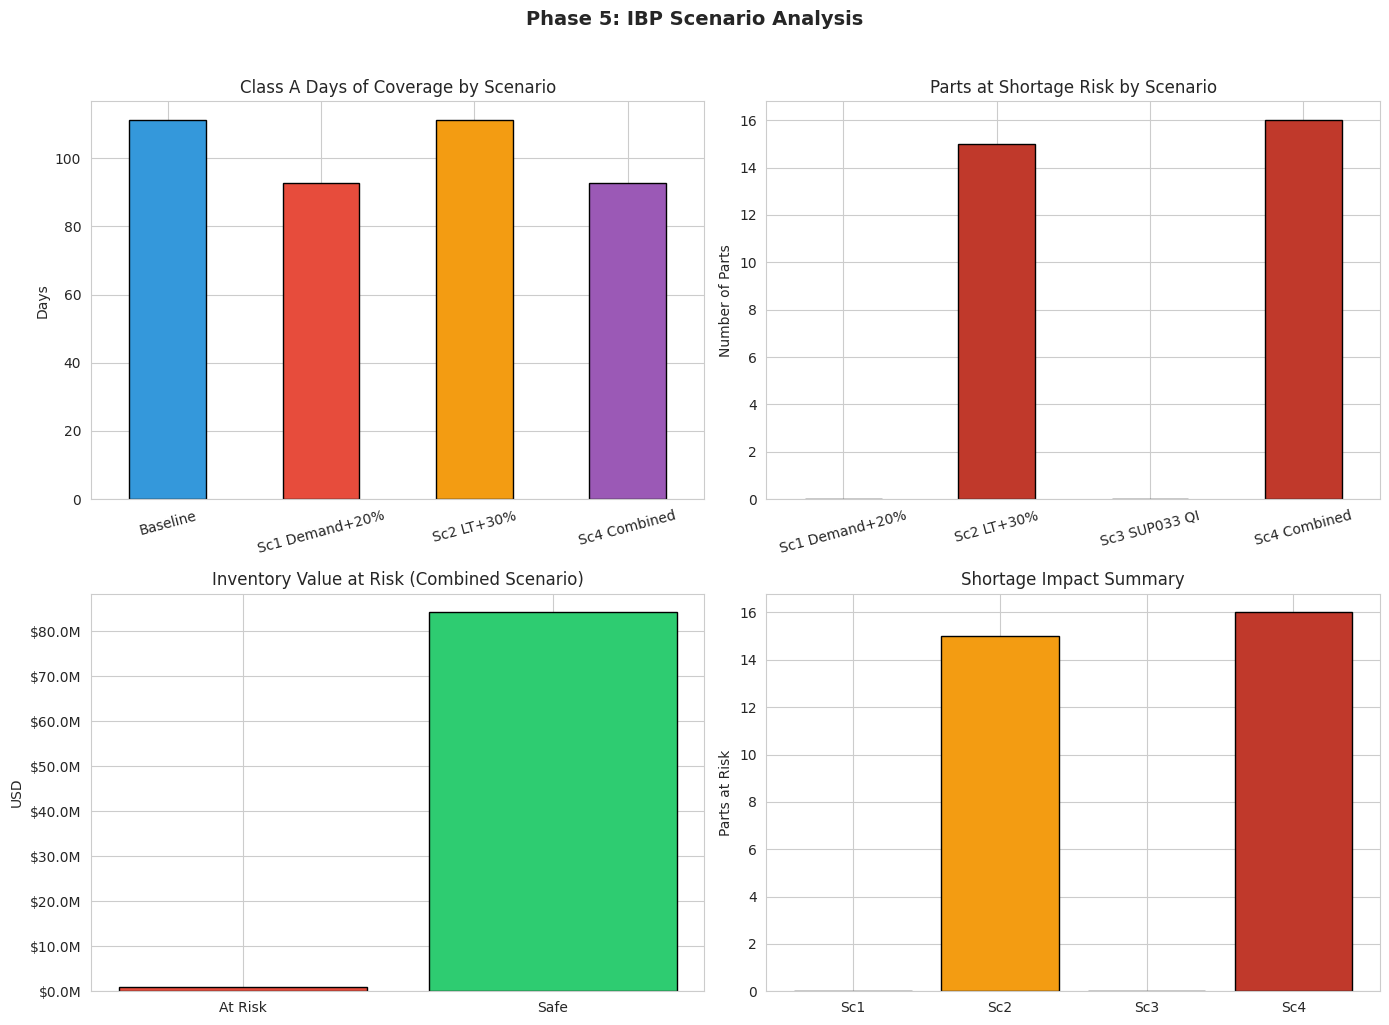

In [8]:
total_inv_value = baseline['inventory_value'].sum()
sc4_value_at_risk = sc4.loc[sc4['shortage_risk'], 'inventory_value'].sum()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Days of Coverage: Baseline vs Scenarios (Class A)
scenarios_a = pd.Series({
    'Baseline': baseline.loc[baseline['criticality_class'] == 'A', 'days_of_coverage'].mean(),
    'Sc1 Demand+20%': sc1.loc[mask_a, 'days_of_coverage'].mean(),
    'Sc2 LT+30%': sc2.loc[sc2['criticality_class'] == 'A', 'days_of_coverage'].mean(),
    'Sc4 Combined': sc4.loc[sc4['criticality_class'] == 'A', 'days_of_coverage'].mean(),
})
scenarios_a.plot(kind='bar', ax=axes[0, 0], color=['#3498db', '#e74c3c', '#f39c12', '#9b59b6'], edgecolor='black')
axes[0, 0].set_title('Class A Days of Coverage by Scenario')
axes[0, 0].set_ylabel('Days')
axes[0, 0].tick_params(axis='x', rotation=15)

# 2. Shortage Parts by Scenario
shortage = pd.Series({
    'Sc1 Demand+20%': int(sc1.loc[mask_a, 'shortage_risk'].sum()),
    'Sc2 LT+30%': int(sc2['shortage_risk'].sum()),
    'Sc3 SUP033 QI': int(sc3.loc[mask_033, 'shortage_risk'].sum()),
    'Sc4 Combined': int(sc4['shortage_risk'].sum()),
})
shortage.plot(kind='bar', ax=axes[0, 1], color='#c0392b', edgecolor='black')
axes[0, 1].set_title('Parts at Shortage Risk by Scenario')
axes[0, 1].set_ylabel('Number of Parts')
axes[0, 1].tick_params(axis='x', rotation=15)

# 3. Inventory Value at Risk (Sc4, the worst case)
axes[1, 0].bar(['At Risk', 'Safe'], [sc4_value_at_risk, total_inv_value - sc4_value_at_risk],
               color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1, 0].set_title('Inventory Value at Risk (Combined Scenario)')
axes[1, 0].set_ylabel('USD')
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# 4. Summary Impact (shortage parts as a simple severity proxy)
impact = pd.DataFrame({
    'Scenario': ['Sc1', 'Sc2', 'Sc3', 'Sc4'],
    'Shortage_Parts': [shortage['Sc1 Demand+20%'], shortage['Sc2 LT+30%'], shortage['Sc3 SUP033 QI'], shortage['Sc4 Combined']],
})
axes[1, 1].bar(impact['Scenario'], impact['Shortage_Parts'],
               color=['#3498db', '#f39c12', '#9b59b6', '#c0392b'], edgecolor='black')
axes[1, 1].set_title('Shortage Impact Summary')
axes[1, 1].set_ylabel('Parts at Risk')

plt.suptitle('Phase 5: IBP Scenario Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'phase5_ibp_scenario_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Export Results

In [9]:
sc3_value_affected = sc3.loc[mask_033, 'inventory_value'].sum()

with open(DATA_PROCESSED / "phase5_summary.txt", "w") as f:
    f.write("Phase 5 Summary - IBP Scenario Planning\n")
    f.write("=" * 50 + "\n")
    f.write(f"Baseline Inventory: ${total_inv_value/1e6:.2f}M\n")
    f.write(f"Sc1 Class A Demand +20%: Days Cover {sc1.loc[mask_a, 'days_of_coverage'].mean():.1f}, Shortage {int(sc1.loc[mask_a, 'shortage_risk'].sum())}\n")
    f.write(f"Sc2 Lead Time +30%: Shortage {int(sc2['shortage_risk'].sum())} parts (mostly Class C)\n")
    f.write(f"Sc3 SUP033 Quality 50% blocked: Impact ${sc3_value_affected/1e6:.1f}M, Shortage {int(sc3.loc[mask_033, 'shortage_risk'].sum())}\n")
    f.write(f"Sc4 Combined Shock: Shortage {int(sc4['shortage_risk'].sum())} parts, Value at Risk ${sc4_value_at_risk/1e6:.2f}M\n")
    f.write("\nKey Insight: High excess inventory provides a strong buffer against shocks.\n")
    f.write("Recommendation: Reduce excess systematically while dual-sourcing high-risk suppliers.\n")

print("Export complete ->", DATA_PROCESSED)
print("Files:", sorted(p.name for p in DATA_PROCESSED.iterdir()))


Export complete -> /home/claude/repo/End-to-End-Aerospace-Supply-Chain-Planning/data/processed/phase5
Files: ['phase5_summary.txt']


## Key Takeaways — Phase 5

1. **The current excess-inventory position is functioning as a genuine shock absorber.** None of the four scenarios pushed a large share of inventory value into shortage risk, even under a combined demand-and-lead-time shock.
2. **Lead-time risk (Scenario 2), not demand risk (Scenario 1), is the more dangerous single shock**, and it concentrates in Class C parts rather than Class A — a useful and non-obvious result for prioritizing mitigation.
3. **The SUP033 quality scenario confirms Phase 4's supplier risk ranking is operationally meaningful**: it is the single highest-risk supplier, and a plausible quality event there puts real inventory value in play.

## Overall Project Conclusion

Combining all five phases: the network sustains high service levels primarily through excess inventory rather than reliable supply (Phase 1, 3). Forecasting accuracy is adequate for the bulk of the catalog but the manual adjustment step is not adding value (Phase 2). Supplier risk is concentrated in a small number of suppliers, several of which hold Class A parts (Phase 4). Under stress-testing, the excess inventory is doing real protective work (Phase 5) — so the recommended path forward is a **phased, risk-aware inventory reduction** (start with low-criticality excess, retain buffer against lead-time risk) run in parallel with **supplier risk mitigation** (dual-sourcing or development plans for SUP033, SUP013, SUP038) rather than either lever pulled in isolation.
